In [ ]:
import numpy as np
import networkx as nx

adj_path = "path-to-dataset"

In [ ]:
adj = np.load(adj_path)
G = nx.from_numpy_array(adj)

In [129]:
len(G.nodes())

8600

In [ ]:
def get_k_hop_subgraph_num_nx(G, k):
    """
    adj: numpy.ndarray, shape [N, N], 0/1 adjacency matrix
    k: int, number of steps
    returns: numpy.ndarray, length N
    """
    N = adj.shape[0]
    neighbor_nums = np.zeros(N, dtype=int)

    for node in range(N):
        reachable = nx.single_source_shortest_path_length(G, node, cutoff=k)
        neighbor_nums[node] = len(reachable)
    print(sum(neighbor_nums)/N)
    return neighbor_nums

def plot_neighbor_num_distribution(neighbor_nums, title='Node Neighbor Number Distribution'):
    import matplotlib.pyplot as plt
    bins = np.arange(0, max(neighbor_nums) + 1, 1)
    plt.figure(figsize=(10, 6))
    plt.hist(neighbor_nums, bins=bins, color='blue', alpha=0.7)
    plt.xlabel('Neighbor Num', fontsize=16)
    plt.ylabel('Node Num', fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    # plt.xlim(0, 360)
    plt.grid(True)
    plt.savefig('CA_node.pdf', bbox_inches='tight')
    plt.show()

In [131]:
hop1 = get_k_hop_subgraph_num_nx(G, 1)

29.316046511627906


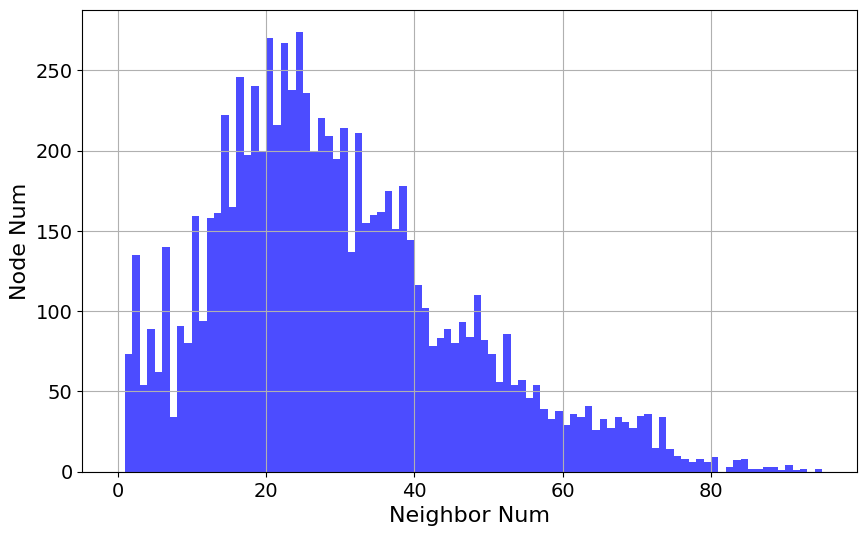

In [132]:
plot_neighbor_num_distribution(hop1, title='1-Hop within Neighbor Number Distribution')